# TP Module 3 — Modèles de diffusion : DDPM & DDIM (DermaMNIST)

**Formation avancée en Deep Learning avec PyTorch — Computer Vision & Séries temporelles**

*Bassem Ben Hamed — ENETCOM, Université de Sfax*

---

## Objectifs du TP

1. Formuler le **processus avant** (bruitage progressif, chaîne de Markov) et sa propriété clé : le **saut direct** $\mathbf{x}_t = \sqrt{\bar\alpha_t}\,\mathbf{x}_0 + \sqrt{1-\bar\alpha_t}\,\boldsymbol{\epsilon}$
2. Comprendre comment l'objectif variationnel du **DDPM** (Ho et al., 2020) se réduit à une **régression de débruitage** : $L_{\text{simple}} = \|\boldsymbol{\epsilon} - \boldsymbol{\epsilon}_\theta(\mathbf{x}_t, t)\|^2$
3. Implémenter **from scratch** le *noise scheduler* (linéaire vs cosinus), vérifié numériquement
4. Construire un **U-Net conditionné par le timestep** : *time embedding* sinusoïdal, blocs résiduels **GroupNorm + SiLU**, **self-attention** en basse résolution
5. Entraîner le DDPM sur DermaMNIST et **échantillonner** par la boucle ancestrale ($T$ passes réseau)
6. Implémenter le sampling **DDIM** : déterministe, $S \ll T$ pas, **sans réentraîner** — accélération mesurée
7. Situer la diffusion parmi les modèles génératifs (AE → VAE → diffusion, GAN au Module 4) et découvrir le prototypage avec `diffusers`

## Pré-requis

- Modules 1 et 2, **TP 07** (U-Net, débruitage) et **TP 08** (VAE — la borne variationnelle est la même machinerie)
- `torch`, `torchvision`, `medmnist`, `matplotlib`, `numpy` ; **optionnel** : `diffusers`

## Dataset

Toujours le **fil rouge médical** sur **DermaMNIST** (collection [MedMNIST](https://medmnist.com/), dérivé de HAM10000) — images dermatoscopiques **RGB**, 7 classes. L'entraînement est **non supervisé** (aucun label). ⚠️ La diffusion est **gourmande en calcul** : on travaille ici à la **résolution native 28×28** pour rester exécutable sur CPU ($T$ passes réseau par échantillon DDPM !) — un **GPU est fortement recommandé** pour passer en 64×64. Téléchargement automatique via `medmnist` dans `./data/`.

## Partie I — Théorie des modèles de diffusion

### I.1 Intuition & processus avant

Idée (analogie de la goutte d'encre qui se dilue) : **bruiter est trivial, débruiter est difficile** — on simule donc le bruitage, et on apprend à « rembobiner le film ». Le **processus avant** (*forward / diffusion*) est une chaîne de Markov **fixée, sans paramètre**, qui ajoute progressivement du bruit gaussien selon un *noise schedule* $\{\beta_t\}_{t=1}^{T}$ :

$$
q(\mathbf{x}_t\,|\,\mathbf{x}_{t-1}) = \mathcal{N}\bigl(\mathbf{x}_t;\ \sqrt{1-\beta_t}\,\mathbf{x}_{t-1},\ \beta_t\mathbf{I}\bigr),
\qquad
q(\mathbf{x}_{1:T}\,|\,\mathbf{x}_0) = \prod_{t=1}^{T} q(\mathbf{x}_t\,|\,\mathbf{x}_{t-1}).
$$

Pour $T$ grand et des $\beta_t$ petits, $\mathbf{x}_T \approx \mathcal{N}(\mathbf{0},\mathbf{I})$ : l'information de $\mathbf{x}_0$ est entièrement détruite. Le **processus inverse** $p_\theta(\mathbf{x}_{t-1}|\mathbf{x}_t)$ — débruiter pas à pas — est ce que le réseau apprend.

### I.2 Propriété clé : saut direct vers $\mathbf{x}_t$

Posons $\alpha_t = 1-\beta_t$ et $\bar\alpha_t = \prod_{s=1}^{t}\alpha_s$. La composition de gaussiennes donne la **marginale en forme close** — *sans itérer* :

$$
\boxed{\;q(\mathbf{x}_t\,|\,\mathbf{x}_0) = \mathcal{N}\bigl(\mathbf{x}_t;\ \sqrt{\bar\alpha_t}\,\mathbf{x}_0,\ (1-\bar\alpha_t)\mathbf{I}\bigr)\;}
\quad\Longleftrightarrow\quad
\mathbf{x}_t = \sqrt{\bar\alpha_t}\,\mathbf{x}_0 + \sqrt{1-\bar\alpha_t}\,\boldsymbol{\epsilon},
\ \ \boldsymbol{\epsilon}\sim\mathcal{N}(\mathbf{0},\mathbf{I}).
$$

On génère donc $\mathbf{x}_t$ à **n'importe quel pas $t$ en une seule opération** — crucial pour l'entraînement.

**Exemple numérique** (pixel scalaire, celui du cours) : $\bar\alpha_t = 0.64 \Rightarrow \sqrt{\bar\alpha_t}=0.8$, $\sqrt{1-\bar\alpha_t}=0.6$. Avec $x_0=1.0$ et $\epsilon=0.5$ :

$$
x_t = 0.8\cdot 1.0 + 0.6\cdot 0.5 = 1.1,
\qquad
\mathrm{SNR}(t) = \frac{\bar\alpha_t}{1-\bar\alpha_t} = \frac{0.64}{0.36} \approx 1.78 .
$$

**Postérieur avant conditionné (tractable).** Connaissant $\mathbf{x}_0$, le pas inverse idéal est gaussien et calculable :

$$
q(\mathbf{x}_{t-1}\,|\,\mathbf{x}_t,\mathbf{x}_0) = \mathcal{N}(\tilde{\boldsymbol{\mu}}_t,\ \tilde\beta_t\mathbf{I}),
\qquad
\tilde\beta_t = \frac{1-\bar\alpha_{t-1}}{1-\bar\alpha_t}\,\beta_t .
$$

C'est la **cible** que le réseau doit imiter *sans connaître* $\mathbf{x}_0$.

### I.3 Processus inverse, prédiction du bruit & loss simplifiée

**Processus inverse paramétré** (Ho et al., 2020) : $p_\theta(\mathbf{x}_{t-1}|\mathbf{x}_t) = \mathcal{N}\bigl(\boldsymbol{\mu}_\theta(\mathbf{x}_t,t),\ \sigma_t^2\mathbf{I}\bigr)$, en partant de $\mathbf{x}_T\sim\mathcal{N}(\mathbf{0},\mathbf{I})$.

**Borne variationnelle** — mêmes outils que le VAE (TP 08) :

$$
\mathbb{E}\bigl[-\log p_\theta(\mathbf{x}_0)\bigr] \le \mathbb{E}_q\Bigl[
\underbrace{\mathrm{KL}\bigl(q(\mathbf{x}_T|\mathbf{x}_0)\,\|\,p(\mathbf{x}_T)\bigr)}_{L_T\ (\text{constante})}
+ \sum_{t>1} L_{t-1}
+ \underbrace{L_0}_{-\log p_\theta(\mathbf{x}_0|\mathbf{x}_1)}\Bigr],
\qquad
L_{t-1} = \mathrm{KL}\bigl(q(\mathbf{x}_{t-1}|\mathbf{x}_t,\mathbf{x}_0)\,\|\,p_\theta(\mathbf{x}_{t-1}|\mathbf{x}_t)\bigr).
$$

Tout l'apprentissage est dans les $L_{t-1}$ : imiter le pas inverse idéal à chaque $t$. En injectant $\mathbf{x}_0 = \tfrac{1}{\sqrt{\bar\alpha_t}}(\mathbf{x}_t - \sqrt{1-\bar\alpha_t}\,\boldsymbol{\epsilon})$, la moyenne optimale se **reparamétrise comme une prédiction du bruit** :

$$
\boldsymbol{\mu}_\theta(\mathbf{x}_t,t) = \frac{1}{\sqrt{\alpha_t}}\Bigl(\mathbf{x}_t - \frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\,\boldsymbol{\epsilon}_\theta(\mathbf{x}_t,t)\Bigr).
$$

**Objectif simplifié.** En ignorant la pondération issue de la KL (Ho et al. montrent que cela *améliore* la qualité), toute la machinerie variationnelle se réduit à une **régression de débruitage** :

$$
L_{\text{simple}} = \mathbb{E}_{t\sim\mathcal{U}\{1,T\},\ \mathbf{x}_0,\ \boldsymbol{\epsilon}}
\Bigl[\ \bigl\|\,\boldsymbol{\epsilon} - \boldsymbol{\epsilon}_\theta\bigl(\sqrt{\bar\alpha_t}\,\mathbf{x}_0 + \sqrt{1-\bar\alpha_t}\,\boldsymbol{\epsilon},\ t\bigr)\bigr\|_2^2\ \Bigr].
$$

**Algorithme 1 (training)** : $\mathbf{x}_0\sim\mathcal{D}$ → $t\sim\mathcal{U}\{1,\dots,T\}$ → $\boldsymbol{\epsilon}\sim\mathcal{N}(\mathbf{0},\mathbf{I})$ → saut direct vers $\mathbf{x}_t$ → pas de gradient sur $\|\boldsymbol{\epsilon}-\boldsymbol{\epsilon}_\theta(\mathbf{x}_t,t)\|^2$. Le réseau **devine le bruit ajouté** — rien de plus.

### I.4 Échantillonnage DDPM (boucle ancestrale)

Partant de $\mathbf{x}_T\sim\mathcal{N}(\mathbf{0},\mathbf{I})$, pour $t=T,\dots,1$ :

$$
\mathbf{x}_{t-1} = \frac{1}{\sqrt{\alpha_t}}\Bigl(\mathbf{x}_t - \frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\,\boldsymbol{\epsilon}_\theta(\mathbf{x}_t,t)\Bigr) + \sigma_t\mathbf{z},
$$

avec $\mathbf{z}\sim\mathcal{N}(\mathbf{0},\mathbf{I})$ si $t>1$ (sinon $\mathbf{z}=\mathbf{0}$), et $\sigma_t^2 = \tilde\beta_t$ (ou $\beta_t$, choix de Ho et al. que nous suivons). Chaque itération = **1 forward du U-Net** + une injection de bruit.

⚠️ **Coût** : DDPM exige $T$ passes réseau (typiquement $T=1000$) **par lot d'échantillons** → génération lente. C'est exactement le problème que résout **DDIM** (I.7).

### I.5 Noise schedule : linéaire vs cosinus

Le choix des $\{\beta_t\}$ contrôle la **vitesse de destruction du signal** :

- **Linéaire** (Ho et al., 2020) : $\beta_t$ croît linéairement de $10^{-4}$ à $0.02$ ($T=1000$). Simple, mais détruit le signal trop vite en fin de chaîne.
- **Cosinus** (Nichol & Dhariwal, 2021) : on définit directement

$$
\bar\alpha_t = \frac{f(t)}{f(0)},
\qquad
f(t) = \cos^2\!\Bigl(\frac{t/T + s}{1 + s}\cdot\frac{\pi}{2}\Bigr),
\quad s = 0.008 .
$$

Le SNR décroît plus doucement — plus de signal conservé au milieu de la chaîne → meilleure qualité (on comparera les deux courbes en Partie III).

### I.6 U-Net conditionné par le timestep — et la lecture *score-based*

Le réseau $\boldsymbol{\epsilon}_\theta(\mathbf{x}_t, t)$ est un **U-Net** (TP 07 !) avec les composants standards des diffusion models :

- encodeur-décodeur convolutif avec **skip connections** (le débruitage exige les détails fins) ;
- **GroupNorm + SiLU** (Swish) au lieu de BatchNorm — insensible à la taille de batch, standard du domaine ;
- **blocs résiduels** à chaque résolution ;
- **self-attention** aux résolutions basses ($16^2$, $8^2$ — ici $7^2$) ;
- **time embedding** : $t$ est encodé en *positional encoding sinusoïdal*, projeté par un MLP, puis **injecté dans chaque bloc résiduel** (addition). Un **seul** réseau $\boldsymbol{\epsilon}_\theta(\cdot, t)$ sert pour tous les $t$.

**Vue score-based** (Song & Ermon, 2019). Le **score** d'une densité est $\mathbf{s}(\mathbf{x}) = \nabla_{\mathbf{x}}\log p(\mathbf{x})$ — une boussole qui pointe vers les zones de forte densité. Sur la marginale bruitée, la relation est exacte :

$$
\nabla_{\mathbf{x}_t}\log q(\mathbf{x}_t|\mathbf{x}_0) = -\frac{\boldsymbol{\epsilon}}{\sqrt{1-\bar\alpha_t}}
\quad\Longrightarrow\quad
\mathbf{s}_\theta(\mathbf{x}_t,t) = -\frac{\boldsymbol{\epsilon}_\theta(\mathbf{x}_t,t)}{\sqrt{1-\bar\alpha_t}} .
$$

Prédire le bruit **équivaut** à estimer le score : DDPM (discret) et modèles score-based (SDE continue, Song et al., 2021) sont deux faces du même cadre — c'est ce qui justifie les solveurs rapides type DPM-Solver.

### I.7 DDIM : échantillonnage accéléré & déterministe

**DDIM** (Song, Meng & Ermon, 2021) réutilise **le même réseau** $\boldsymbol{\epsilon}_\theta$ — aucun réentraînement — mais redéfinit le pas inverse (processus *non markovien*). À chaque pas, on **estime l'image finale** puis on « re-bruite » juste au niveau $t-1$ :

$$
\hat{\mathbf{x}}_0 = \frac{\mathbf{x}_t - \sqrt{1-\bar\alpha_t}\,\boldsymbol{\epsilon}_\theta(\mathbf{x}_t,t)}{\sqrt{\bar\alpha_t}},
\qquad
\mathbf{x}_{t-1} = \sqrt{\bar\alpha_{t-1}}\,\hat{\mathbf{x}}_0 + \sqrt{1-\bar\alpha_{t-1}-\sigma_t^2}\,\boldsymbol{\epsilon}_\theta + \sigma_t\mathbf{z}.
$$

C'est ce qui autorise de **grands sauts** : on échantillonne sur une **sous-suite** $\{\tau_1,\dots,\tau_S\}\subset\{1,\dots,T\}$ avec $S\ll T$ ($S=20$–$50$) → accélération $\times 10$ à $\times 50$.

- **Cas déterministe $\sigma_t = 0$** : la trajectoire $\mathbf{x}_T\to\mathbf{x}_0$ devient une **ODE déterministe** — même $\mathbf{x}_T$ ⟹ même image (latent reproductible, interpolation possible).
- DDPM ($\sigma_t = \sqrt{\tilde\beta_t}$) et DDIM ($\sigma_t = 0$) sont les **deux extrêmes d'une famille** paramétrée par $\sigma_t$ (le $\eta$ de l'exercice 3).

## Partie II — Préparation des données

Deux différences avec les TP 07/08 :

- **résolution native 28×28** (coût : $T$ passes U-Net par échantillon DDPM — le 64×64 est pour GPU) ;
- pixels normalisés dans $[-1, 1]$ (et non $[0,1]$) : $\mathbf{x}_T$ doit suivre $\mathcal{N}(\mathbf{0},\mathbf{I})$, il faut des données **centrées** — convention universelle des diffusion models. La sortie du U-Net (le bruit $\boldsymbol{\epsilon}$) n'est **pas bornée** : pas de sigmoïde.

In [1]:
import os
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision.transforms import v2 as T_
from medmnist import DermaMNIST, INFO

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {device}")

ROOT     = Path("./data")
CKPT_DIR = Path("./checkpoints")
ROOT.mkdir(exist_ok=True); CKPT_DIR.mkdir(exist_ok=True)

IMG_SIZE = 28                 # résolution NATIVE MedMNIST — CPU-friendly (GPU recommandé pour 64)
BATCH    = 128

info          = INFO["dermamnist"]
NUM_CLASSES   = len(info["label"])
CLASSES_SHORT = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
print(f"Dataset  : DermaMNIST {IMG_SIZE}×{IMG_SIZE}, {NUM_CLASSES} classes (labels NON utilisés)")

PyTorch  : 2.10.0
Device   : cpu
Dataset  : DermaMNIST 28×28, 7 classes (labels NON utilisés)


Train : 7007  |  Test : 2005
Tenseur image : (3, 28, 28)  min=-0.27  max=0.78


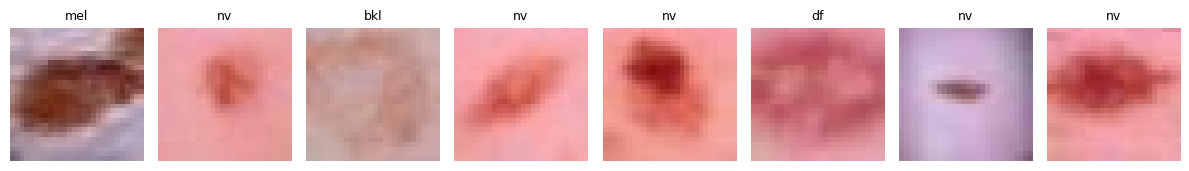

Batch : (128, 3, 28, 28)


In [2]:
def make_derma(split, transform=None, target_transform=None):
    '''Charge un split DermaMNIST en demandant size=IMG_SIZE (RGB natif),
    avec repli si la version de medmnist ne connaît pas `size`.'''
    kwargs = dict(split=split, root=ROOT, download=True,
                  transform=transform, target_transform=target_transform)
    try:
        return DermaMNIST(size=IMG_SIZE, **kwargs)
    except TypeError:
        return DermaMNIST(**kwargs)            # medmnist < 3.0 : images 28×28

def squeeze_target(t):                          # cf. TP 07/08 (pas un lambda : pickling)
    return int(np.asarray(t).reshape(-1)[0])

# [0,255] -> float [0,1] -> [-1,1]  (donnees centrees : x_T ~ N(0,I))
to_tensor = T_.Compose([
    T_.ToImage(),
    T_.ToDtype(torch.float32, scale=True),
    T_.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

def to01(x):
    '''[-1,1] -> [0,1] pour l'affichage.'''
    return (x.clamp(-1, 1) + 1) / 2

train_set = make_derma("train", transform=to_tensor, target_transform=squeeze_target)
test_set  = make_derma("test",  transform=to_tensor, target_transform=squeeze_target)
print(f"Train : {len(train_set)}  |  Test : {len(test_set)}")
x0_, y0_ = train_set[0]
print(f"Tenseur image : {tuple(x0_.shape)}  min={x0_.min():.2f}  max={x0_.max():.2f}")

train_loader = DataLoader(train_set, batch_size=BATCH, shuffle=True,  num_workers=0, drop_last=True)
test_loader  = DataLoader(test_set,  batch_size=BATCH, shuffle=False, num_workers=0)

def show_grid(imgs, titles=None, nrow=8, figsize=None, cmap=None):
    '''Affiche une grille d'images (tenseurs CHW dans [0,1]).'''
    n = len(imgs)
    ncol = nrow
    nrows = (n + ncol - 1) // ncol
    figsize = figsize or (1.5 * ncol, 1.7 * nrows)
    fig, axes = plt.subplots(nrows, ncol, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()
    for i, ax in enumerate(axes):
        ax.axis("off")
        if i < n:
            img = imgs[i].detach().cpu().clamp(0, 1).permute(1, 2, 0).numpy()
            ax.imshow(img, cmap=cmap)
            if titles is not None:
                ax.set_title(titles[i], fontsize=9)
    plt.tight_layout(); plt.show()

x_batch, y_batch = next(iter(train_loader))
show_grid([to01(x_batch[i]) for i in range(8)],
          titles=[CLASSES_SHORT[int(y_batch[i])] for i in range(8)])
print(f"Batch : {tuple(x_batch.shape)}")

## Partie III — Noise scheduler *from scratch*

Trois tenseurs précalculés suffisent : $\beta_t$ (`torch.linspace`), $\alpha_t = 1-\beta_t$ et $\bar\alpha_t$ (`torch.cumprod`). La fonction `q_sample` implémente le **saut direct** de I.2. On vérifie :

1. l'**exemple numérique du cours** ($\bar\alpha_t = 0.64$ : $x_t = 1.1$, SNR $\approx 1.78$) ;
2. que $\bar\alpha_T \approx 0$ — le signal est bien détruit, $\mathbf{x}_T$ a une moyenne $\approx 0$ et un écart-type $\approx 1$.

In [3]:
T = 1000
betas  = torch.linspace(1e-4, 0.02, T, device=device)   # schedule linéaire (Ho et al., 2020)
alphas = 1.0 - betas
abar   = torch.cumprod(alphas, dim=0)                   # alpha_bar_t

def q_sample(x0, t, eps):
    '''Saut direct : x_t = sqrt(abar_t) x0 + sqrt(1-abar_t) eps  (t : tenseur d'indices).'''
    a = abar[t].sqrt().view(-1, 1, 1, 1)
    b = (1 - abar[t]).sqrt().view(-1, 1, 1, 1)
    return a * x0 + b * eps

# --- 1) Exemple numérique du cours : abar = 0.64 ---
t64 = int((abar - 0.64).abs().argmin())
print(f"abar_t = 0.64 atteint à t = {t64}  (abar[{t64}] = {abar[t64]:.4f})")
x0_px, eps_px = 1.0, 0.5
xt_px = abar[t64].sqrt() * x0_px + (1 - abar[t64]).sqrt() * eps_px
snr   = abar[t64] / (1 - abar[t64])
print(f"x_t = 0.8·1.0 + 0.6·0.5 = {xt_px:.2f}   (cours : 1.1)")
print(f"SNR(t) = {snr:.2f}                      (cours : ≈ 1.78)")

# --- 2) Destruction du signal en fin de chaîne ---
print(f"\nabar_T = {abar[-1]:.2e}  ->  sqrt(abar_T) = {abar[-1].sqrt():.4f} : signal résiduel négligeable")
x = x_batch.to(device)
xT = q_sample(x, torch.full((len(x),), T - 1, device=device), torch.randn_like(x))
print(f"x_T : mean = {xT.mean():.3f}  std = {xT.std():.3f}   (attendu ≈ 0 et ≈ 1 : x_T ~ N(0, I))")

abar_t = 0.64 atteint à t = 206  (abar[206] = 0.6402)
x_t = 0.8·1.0 + 0.6·0.5 = 1.10   (cours : 1.1)
SNR(t) = 1.78                      (cours : ≈ 1.78)

abar_T = 4.04e-05  ->  sqrt(abar_T) = 0.0064 : signal résiduel négligeable
x_T : mean = 0.001  std = 1.001   (attendu ≈ 0 et ≈ 1 : x_T ~ N(0, I))


**Interprétation — le processus avant, validé numériquement.** Trois vérifications conformes au cours : (1) le **saut direct** $x_t=\sqrt{\bar\alpha_t}\,x_0+\sqrt{1-\bar\alpha_t}\,\epsilon$ donne, pour $\bar\alpha_t=0.64$, **$x_t=0.8\cdot1.0+0.6\cdot0.5=1.10$** et un **SNR $=\bar\alpha_t/(1-\bar\alpha_t)\approx1.78$** — exactement l'exemple numérique du deck ; (2) en fin de chaîne, $\bar\alpha_T\approx4\times10^{-5}$ : le **signal résiduel est négligeable** ; (3) l'image $x_T$ obtenue a **moyenne ≈ 0 et écart-type ≈ 1**, soit bien $\mathcal{N}(0,I)$. Le processus avant n'a **aucun paramètre appris** : c'est cette forme close qui permet de fabriquer $x_t$ à **n'importe quel $t$ en une seule opération**, et donc d'entraîner efficacement.

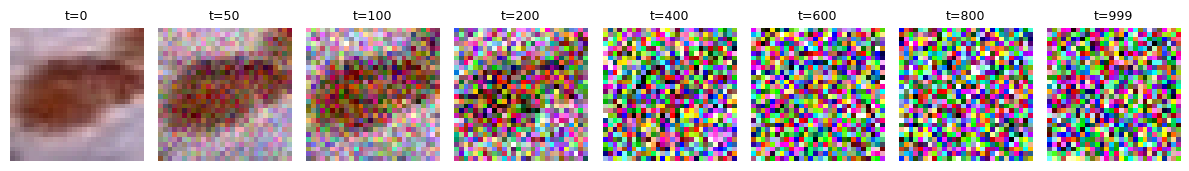

Le contenu s'efface progressivement ; à t≈1000 il ne reste que du bruit gaussien.


In [4]:
# Visualisation du processus avant : une image bruitée à différents t
ts_show = [0, 50, 100, 200, 400, 600, 800, 999]
x_one = x_batch[0:1].to(device)
torch.manual_seed(SEED)
noisy = [q_sample(x_one, torch.tensor([t], device=device), torch.randn_like(x_one))[0]
         for t in ts_show]
show_grid([to01(img) for img in noisy], nrow=8,
          titles=[f"t={t}" for t in ts_show], figsize=(12, 1.9))
print("Le contenu s'efface progressivement ; à t≈1000 il ne reste que du bruit gaussien.")

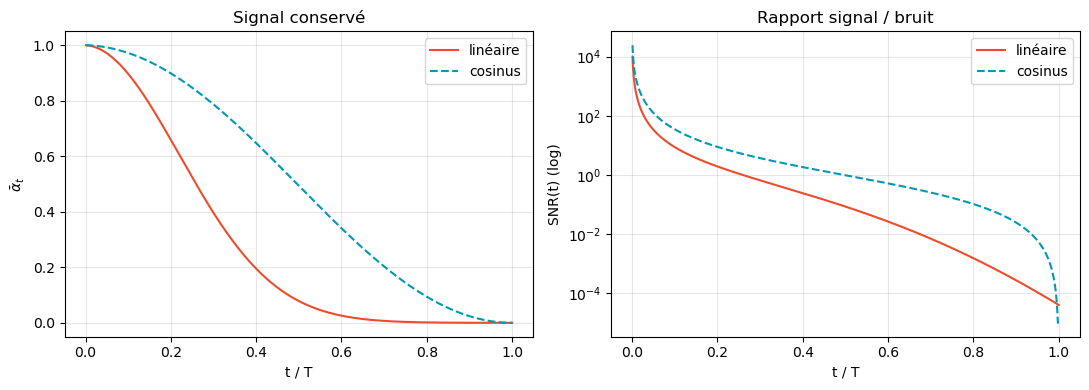

Le cosinus garde plus de signal au milieu de la chaîne (SNR décroît plus doucement) — exercice 1.


In [5]:
# Schedule linéaire vs cosinus : courbes abar_t et SNR
def cosine_abar(T, s=0.008):
    '''Schedule cosinus (Nichol & Dhariwal, 2021) : définit directement abar_t.'''
    t = torch.arange(T + 1, dtype=torch.float32)
    f = torch.cos(((t / T) + s) / (1 + s) * np.pi / 2) ** 2
    return (f[1:] / f[0]).clamp(1e-5, 1.0)

abar_cos = cosine_abar(T)
tt = np.arange(1, T + 1) / T

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(tt, abar.cpu(),  color="#EE4C2C", label="linéaire")
axes[0].plot(tt, abar_cos, "--", color="#0099B3", label="cosinus")
axes[0].set_xlabel("t / T"); axes[0].set_ylabel(r"$\bar\alpha_t$")
axes[0].set_title("Signal conservé"); axes[0].legend(); axes[0].grid(alpha=.3)
axes[1].semilogy(tt, (abar / (1 - abar)).cpu(),  color="#EE4C2C", label="linéaire")
axes[1].semilogy(tt, abar_cos / (1 - abar_cos), "--", color="#0099B3", label="cosinus")
axes[1].set_xlabel("t / T"); axes[1].set_ylabel("SNR(t) (log)")
axes[1].set_title("Rapport signal / bruit"); axes[1].legend(); axes[1].grid(alpha=.3)
plt.tight_layout(); plt.show()
print("Le cosinus garde plus de signal au milieu de la chaîne (SNR décroît plus doucement) — exercice 1.")

**Interprétation — pourquoi le schedule cosinus.** Les deux courbes montrent l'enjeu : avec le schedule **linéaire** (Ho 2020), $\bar\alpha_t$ — et donc le SNR — **chute vite** et les derniers pas n'apportent presque plus de signal. Le schedule **cosinus** (Nichol & Dhariwal 2021) impose à $\bar\alpha_t$ une descente plus **douce** : on **conserve plus de signal au milieu** de la chaîne, d'où des pas inverses mieux conditionnés et, en pratique, une **meilleure qualité** d'échantillons. C'est le seul choix de *design* du processus avant — il ne touche ni l'architecture ni la perte.

## Partie IV — U-Net $\boldsymbol{\epsilon}_\theta(\mathbf{x}_t, t)$

Mini U-Net de diffusion (28 → 14 → 7), avec tous les composants standards de I.6 :

- `SinusoidalTimeEmbedding` + MLP (`Linear → SiLU → Linear`) — le vecteur $\mathbf{t}$ résultant est **injecté par addition** dans chaque `ResBlock` ;
- `ResBlock` : `GroupNorm → SiLU → Conv` ×2 + connexion résiduelle ;
- `AttnBlock` : self-attention (`nn.MultiheadAttention`) sur les positions spatiales, appliquée au **bottleneck** $7\times 7$ (49 tokens) ;
- skips encodeur → décodeur par **concaténation** (comme l'U-Net du TP 07) ;
- sortie : 3 canaux **non bornés** (le bruit prédit $\hat{\boldsymbol{\epsilon}}$).

In [6]:
class SinusoidalTimeEmbedding(nn.Module):
    '''Positional encoding sinusoïdal du timestep t (comme dans le Transformer).'''
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half  = self.dim // 2
        freqs = torch.exp(-np.log(10000.0) * torch.arange(half, device=t.device) / (half - 1))
        ang   = t.float()[:, None] * freqs[None, :]
        return torch.cat([torch.sin(ang), torch.cos(ang)], dim=1)      # (N, dim)

class ResBlock(nn.Module):
    '''GroupNorm -> SiLU -> Conv, ×2, + injection additive du time embedding.'''
    def __init__(self, in_c, out_c, t_dim):
        super().__init__()
        self.norm1 = nn.GroupNorm(8, in_c)
        self.conv1 = nn.Conv2d(in_c, out_c, 3, padding=1)
        self.emb   = nn.Linear(t_dim, out_c)
        self.norm2 = nn.GroupNorm(8, out_c)
        self.conv2 = nn.Conv2d(out_c, out_c, 3, padding=1)
        self.skip  = nn.Conv2d(in_c, out_c, 1) if in_c != out_c else nn.Identity()

    def forward(self, x, t_emb):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.emb(F.silu(t_emb))[:, :, None, None]    # conditionnement par t
        h = self.conv2(F.silu(self.norm2(h)))
        return h + self.skip(x)

class AttnBlock(nn.Module):
    '''Self-attention spatiale : chaque position (H·W tokens) attend sur toutes les autres.'''
    def __init__(self, c, heads=4):
        super().__init__()
        self.norm = nn.GroupNorm(8, c)
        self.attn = nn.MultiheadAttention(c, heads, batch_first=True)

    def forward(self, x):
        N, C, H, W = x.shape
        h = self.norm(x).flatten(2).transpose(1, 2)          # (N, HW, C)
        h, _ = self.attn(h, h, h, need_weights=False)
        return x + h.transpose(1, 2).view(N, C, H, W)

class TinyUNet(nn.Module):
    '''U-Net de diffusion 28 -> 14 -> 7, GroupNorm+SiLU, attention au bottleneck.'''
    def __init__(self, base=32, t_dim=128):
        super().__init__()
        self.t_embed = SinusoidalTimeEmbedding(t_dim)
        self.t_mlp   = nn.Sequential(nn.Linear(t_dim, t_dim), nn.SiLU(), nn.Linear(t_dim, t_dim))
        self.stem = nn.Conv2d(3, base, 3, padding=1)
        # encodeur
        self.e1 = ResBlock(base, base, t_dim)                          # 28×28
        self.down1 = nn.Conv2d(base, base, 3, stride=2, padding=1)     # 28 -> 14
        self.e2 = ResBlock(base, base * 2, t_dim)                      # 14×14
        self.down2 = nn.Conv2d(base * 2, base * 2, 3, stride=2, padding=1)  # 14 -> 7
        # bottleneck (+ attention)
        self.m1 = ResBlock(base * 2, base * 4, t_dim)                  # 7×7
        self.ma = AttnBlock(base * 4)
        self.m2 = ResBlock(base * 4, base * 4, t_dim)
        # décodeur (concat skips, comme au TP 07)
        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, 4, stride=2, padding=1)  # 7 -> 14
        self.r2  = ResBlock(base * 4, base * 2, t_dim)                 # concat e2
        self.up1 = nn.ConvTranspose2d(base * 2, base, 4, stride=2, padding=1)      # 14 -> 28
        self.r1  = ResBlock(base * 2, base, t_dim)                     # concat e1
        self.out = nn.Sequential(nn.GroupNorm(8, base), nn.SiLU(),
                                 nn.Conv2d(base, 3, 3, padding=1))     # eps prédit (non borné)

    def forward(self, x, t):
        temb = self.t_mlp(self.t_embed(t))
        h  = self.stem(x)
        s1 = self.e1(h, temb)                       # (base,   28, 28)
        s2 = self.e2(self.down1(s1), temb)          # (base*2, 14, 14)
        m  = self.m2(self.ma(self.m1(self.down2(s2), temb)), temb)     # (base*4, 7, 7)
        d  = self.r2(torch.cat([self.up2(m), s2], dim=1), temb)        # 14×14
        d  = self.r1(torch.cat([self.up1(d), s1], dim=1), temb)        # 28×28
        return self.out(d)

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

torch.manual_seed(SEED)
unet = TinyUNet().to(device)
with torch.no_grad():
    t_try   = torch.randint(0, T, (4,), device=device)
    eps_try = unet(torch.randn(4, 3, IMG_SIZE, IMG_SIZE, device=device), t_try)
print(f"TinyUNet — paramètres : {count_params(unet):,}")
print(f"Entrée (4, 3, {IMG_SIZE}, {IMG_SIZE}) + t {t_try.tolist()}  ->  sortie {tuple(eps_try.shape)}")

TinyUNet — paramètres : 1,120,579
Entrée (4, 3, 28, 28) + t [635, 620, 143, 670]  ->  sortie (4, 3, 28, 28)


**Interprétation — l'architecture du débruiteur $\epsilon_\theta(x_t,t)$.** Ce `TinyUNet` (1,12 M paramètres) reprend point par point les composants du deck : **encodeur–décodeur convolutif** à **skip connections** (hérité du U-Net du TP 07), **GroupNorm + SiLU** (et non BatchNorm), **blocs résiduels** à chaque résolution, et une **self-attention** au bottleneck ($7\times7$, là où c'est abordable). Le pas $t$ est encodé en **positional encoding sinusoïdal**, projeté par un MLP et **injecté additivement** dans chaque bloc résiduel : un **seul** réseau sert pour **tous** les $t$. C'est l'unique réseau appris de tout le pipeline de diffusion.

## Partie V — Entraînement

L'Algorithme 1 de I.3, mot pour mot : tirer $t$ uniforme, bruiter par **saut direct**, régresser le bruit. Remarquez que **le coût d'une epoch ne dépend pas de $T$** (un seul $t$ par image) — c'est l'échantillonnage qui coûte $T$ passes, pas l'entraînement.

In [7]:
def train_ddpm_epoch(model, loader, optimizer):
    model.train()
    tot, n = 0.0, 0
    for x, _ in loader:
        x = x.to(device, non_blocking=True)
        t   = torch.randint(0, T, (x.size(0),), device=device)   # t ~ U{0..T-1}
        eps = torch.randn_like(x)                                # bruit cible
        x_t = q_sample(x, t, eps)                                # saut direct
        optimizer.zero_grad()
        loss = F.mse_loss(unet(x_t, t), eps)                     # || eps - eps_theta ||^2
        loss.backward()
        optimizer.step()
        tot += loss.item() * x.size(0); n += x.size(0)
    return tot / n

EPOCHS = 30
torch.manual_seed(SEED)
unet = TinyUNet().to(device)
optimizer = torch.optim.Adam(unet.parameters(), lr=2e-4)
hist = []
for ep in range(1, EPOCHS + 1):
    t0 = time.time()
    tr = train_ddpm_epoch(unet, train_loader, optimizer)
    hist.append(tr)
    print(f"[DDPM] epoch {ep:2d}/{EPOCHS}  loss MSE(eps) {tr:.4f}  ({time.time()-t0:.1f}s)")

[DDPM] epoch  1/30  loss MSE(eps) 0.4659  (36.6s)
[DDPM] epoch  2/30  loss MSE(eps) 0.1376  (36.6s)
[DDPM] epoch  3/30  loss MSE(eps) 0.0882  (36.3s)
[DDPM] epoch  4/30  loss MSE(eps) 0.0705  (36.4s)
[DDPM] epoch  5/30  loss MSE(eps) 0.0547  (36.3s)
[DDPM] epoch  6/30  loss MSE(eps) 0.0485  (36.4s)
[DDPM] epoch  7/30  loss MSE(eps) 0.0421  (36.5s)
[DDPM] epoch  8/30  loss MSE(eps) 0.0371  (36.3s)
[DDPM] epoch  9/30  loss MSE(eps) 0.0322  (36.4s)
[DDPM] epoch 10/30  loss MSE(eps) 0.0305  (36.5s)
[DDPM] epoch 11/30  loss MSE(eps) 0.0296  (37.4s)
[DDPM] epoch 12/30  loss MSE(eps) 0.0274  (37.3s)
[DDPM] epoch 13/30  loss MSE(eps) 0.0262  (36.7s)
[DDPM] epoch 14/30  loss MSE(eps) 0.0260  (36.5s)
[DDPM] epoch 15/30  loss MSE(eps) 0.0235  (36.5s)
[DDPM] epoch 16/30  loss MSE(eps) 0.0232  (35.4s)
[DDPM] epoch 17/30  loss MSE(eps) 0.0227  (34.5s)
[DDPM] epoch 18/30  loss MSE(eps) 0.0220  (31.6s)
[DDPM] epoch 19/30  loss MSE(eps) 0.0212  (31.7s)
[DDPM] epoch 20/30  loss MSE(eps) 0.0214  (31.7s)


**Interprétation — toute la machinerie variationnelle se réduit à un MSE.** La perte n'est rien d'autre que $\|\epsilon-\epsilon_\theta(x_t,t)\|_2^2$ : à chaque étape on tire $x_0$, un $t$ uniforme et un bruit $\epsilon$, on fabrique $x_t$ par saut direct, et on demande au réseau de **deviner le bruit ajouté**. La loss tombe de **≈ 0,47 à ≈ 0,02** : le réseau apprend bien à débruiter. Aucun terme KL explicite, aucune instabilité adversariale — d'où la **stabilité d'entraînement** soulignée dans le deck (contrairement au GAN). *Entraîner un modèle de diffusion = entraîner un débruiteur.*

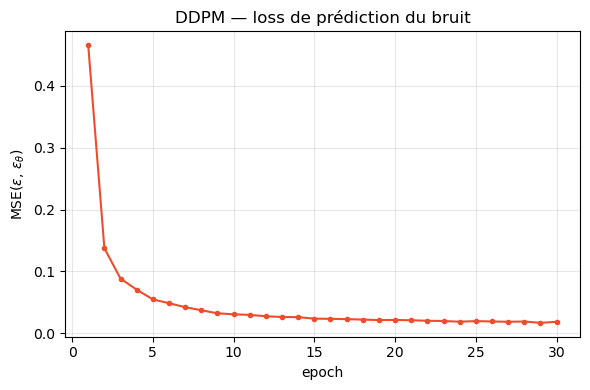

In [8]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, EPOCHS + 1), hist, "-o", ms=3, color="#EE4C2C")
plt.xlabel("epoch"); plt.ylabel(r"MSE($\epsilon$, $\epsilon_\theta$)")
plt.title("DDPM — loss de prédiction du bruit")
plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## Partie VI — Échantillonnage DDPM

La boucle ancestrale de I.4 : $T=1000$ forwards du U-Net **par lot**. On enregistre la trajectoire $\mathbf{x}_t$ à quelques pas pour visualiser le bruit qui « se résout » progressivement en image — le film du processus avant, rembobiné.

DDPM : 16 images en 45.7s  (1000 passes réseau)


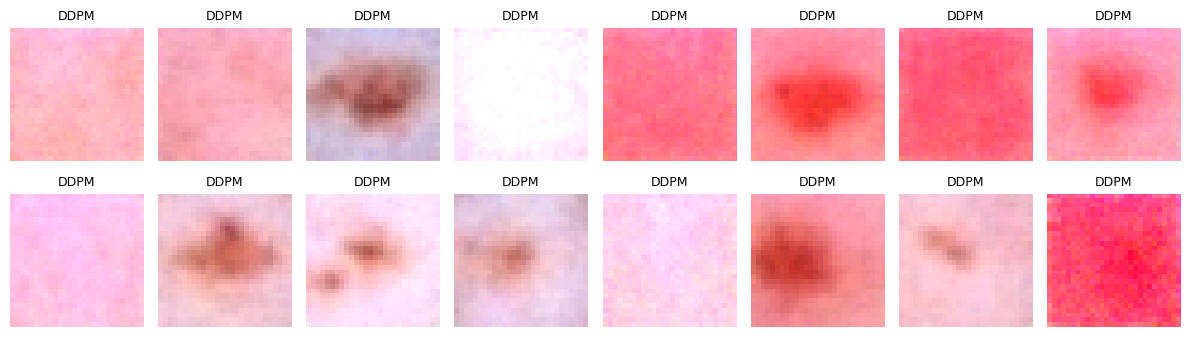

In [9]:
@torch.no_grad()
def ddpm_sample(model, n, record_at=()):
    '''Boucle ancestrale DDPM : T passes réseau. record_at : pas t à mémoriser.'''
    model.eval()
    x = torch.randn(n, 3, IMG_SIZE, IMG_SIZE, device=device)     # x_T ~ N(0, I)
    traj = {}
    for t in reversed(range(T)):
        tb  = torch.full((n,), t, device=device, dtype=torch.long)
        eps = model(x, tb)
        mean = (x - betas[t] / (1 - abar[t]).sqrt() * eps) / alphas[t].sqrt()
        if t > 0:
            x = mean + betas[t].sqrt() * torch.randn_like(x)     # sigma_t = sqrt(beta_t)
        else:
            x = mean                                             # dernier pas : z = 0
        if t in record_at:
            traj[t] = x.clone()
    return x, traj

torch.manual_seed(SEED)
t0 = time.time()
samples, traj = ddpm_sample(unet, 16, record_at=(800, 600, 400, 200, 100, 50, 0))
TIME_DDPM = time.time() - t0
print(f"DDPM : 16 images en {TIME_DDPM:.1f}s  ({T} passes réseau)")
show_grid([to01(img) for img in samples], nrow=8,
          titles=["DDPM"] * 16, figsize=(12, 3.6))

**Interprétation — générer en remontant le bruit.** Partant de **bruit pur** $x_T\sim\mathcal{N}(0,I)$, la boucle ancestrale applique **$T=1000$ pas** de débruitage (un forward du U-Net + réinjection d'un petit bruit à chaque pas, nul au dernier). Résultat : des **lésions plausibles** (peau rosée, centre pigmenté) échantillonnées *de zéro*, mais de **qualité variable** — certaines images restent une peau sans lésion nette. Attendu vu le budget de ce TP (**28×28**, petit U-Net, 30 epochs, **CPU**) ; le deck rappelle que la diffusion est état de l'art en qualité/diversité **à pleine échelle**. Le revers visible ici est le **coût** : ≈ 45 s pour 16 images (1000 passes réseau) — ce que DDIM va corriger.

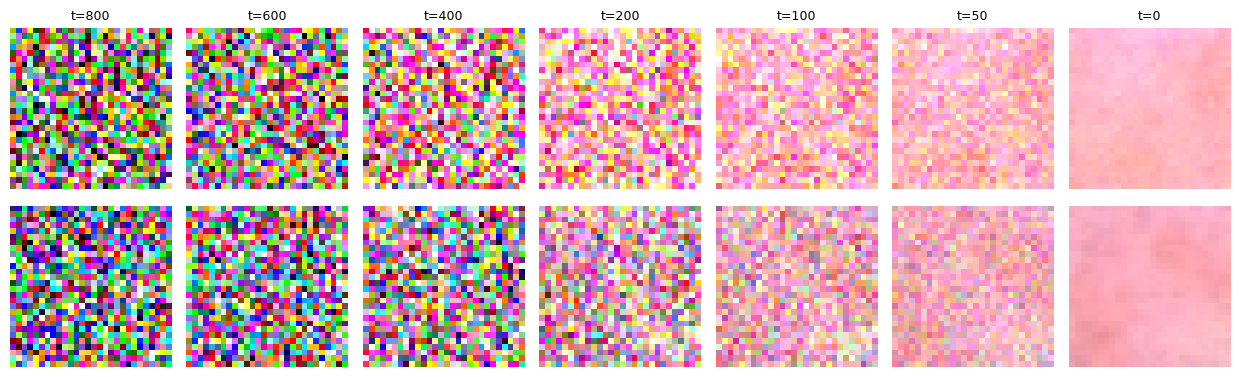

Les basses fréquences (forme, teinte) émergent d'abord ; les détails arrivent aux petits t.


In [10]:
# Trajectoire de débruitage : x_t pour t décroissant (2 échantillons)
ts_rec = [800, 600, 400, 200, 100, 50, 0]
imgs, titles = [], []
for i in range(2):
    for t in ts_rec:
        imgs.append(to01(traj[t][i]))
        titles.append(f"t={t}" if i == 0 else "")
show_grid(imgs, nrow=len(ts_rec), titles=titles, figsize=(12.5, 4))
print("Les basses fréquences (forme, teinte) émergent d'abord ; les détails arrivent aux petits t.")

**Interprétation — une génération *grossier → fin*.** En suivant $x_t$ pour $t$ décroissant, on voit le débruitage **construire l'image par fréquences** : d'abord les **basses fréquences** (forme globale, teinte de la peau) émergent du bruit, puis les **détails** (contour et centre de la lésion) apparaissent aux **petits $t$**. C'est la lecture concrète du processus inverse appris $p_\theta(x_{t-1}\mid x_t)$ : chaque pas rapproche l'échantillon de la variété des images réelles. C'est ce raffinement itératif qui **récupère les hautes fréquences** que le VAE laissait floues (TP 08).

## Partie VII — DDIM : accélérer sans réentraîner

On implémente le pas DDIM de I.7 sur une **sous-suite** de $S$ pas (`torch.linspace(0, T-1, S)`), avec le **même** `unet`. Au menu :

1. accélération **mesurée** vs DDPM ($S=50$ vs $T=1000$) ;
2. **déterminisme** ($\sigma_t = 0$) : deux appels avec le même $\mathbf{x}_T$ donnent la même image, et le même $\mathbf{x}_T$ donne des images *cohérentes* entre différents $S$ ;
3. effet du **nombre de pas** $S \in \{10, 25, 50\}$.

Astuce de stabilité : on **clippe** $\hat{\mathbf{x}}_0$ dans $[-1,1]$ à chaque pas (*static thresholding*) — l'estimée d'image n'a pas le droit de sortir de la dynamique des pixels.

In [11]:
@torch.no_grad()
def ddim_sample(model, n, steps=50, eta=0.0, x_T=None):
    '''Sampling DDIM sur une sous-suite de `steps` pas. eta=0 : déterministe ;
    eta=1 : on retrouve la variance DDPM (beta_tilde). Même réseau, zéro réentraînement.'''
    model.eval()
    taus = torch.linspace(0, T - 1, steps).long()                # sous-suite croissante
    x = x_T.clone() if x_T is not None else torch.randn(n, 3, IMG_SIZE, IMG_SIZE, device=device)
    for i in reversed(range(steps)):
        t      = int(taus[i])
        ab_t   = abar[t]
        ab_prev = abar[int(taus[i - 1])] if i > 0 else torch.tensor(1.0, device=device)
        tb  = torch.full((x.size(0),), t, device=device, dtype=torch.long)
        eps = model(x, tb)
        x0_hat = ((x - (1 - ab_t).sqrt() * eps) / ab_t.sqrt()).clamp(-1, 1)   # prédire x0
        sigma  = eta * (((1 - ab_prev) / (1 - ab_t)) * (1 - ab_t / ab_prev)).sqrt()
        dir_xt = (1 - ab_prev - sigma ** 2).clamp(min=0).sqrt() * eps         # re-bruitage à t-1
        x = ab_prev.sqrt() * x0_hat + dir_xt
        if eta > 0 and i > 0:
            x = x + sigma * torch.randn_like(x)
    return x

# --- 1) Accélération mesurée ---
torch.manual_seed(SEED)
x_T = torch.randn(8, 3, IMG_SIZE, IMG_SIZE, device=device)       # latent commun
t0 = time.time()
gen_ddim = ddim_sample(unet, 8, steps=50, x_T=x_T)
TIME_DDIM = time.time() - t0
print(f"DDIM S=50 : 8 images en {TIME_DDIM:.1f}s  |  DDPM T=1000 : {TIME_DDPM:.1f}s pour 16")
print(f"Accélération ≈ ×{(TIME_DDPM / 16) / (TIME_DDIM / 8):.0f} par image, sans réentraînement")

# --- 2) Déterminisme (sigma = 0) ---
gen_bis = ddim_sample(unet, 8, steps=50, x_T=x_T)
print(f"Même x_T, deux appels : écart max = {(gen_ddim - gen_bis).abs().max():.2e}  (trajectoire = ODE)")

DDIM S=50 : 8 images en 0.6s  |  DDPM T=1000 : 45.7s pour 16
Accélération ≈ ×38 par image, sans réentraînement
Même x_T, deux appels : écart max = 0.00e+00  (trajectoire = ODE)


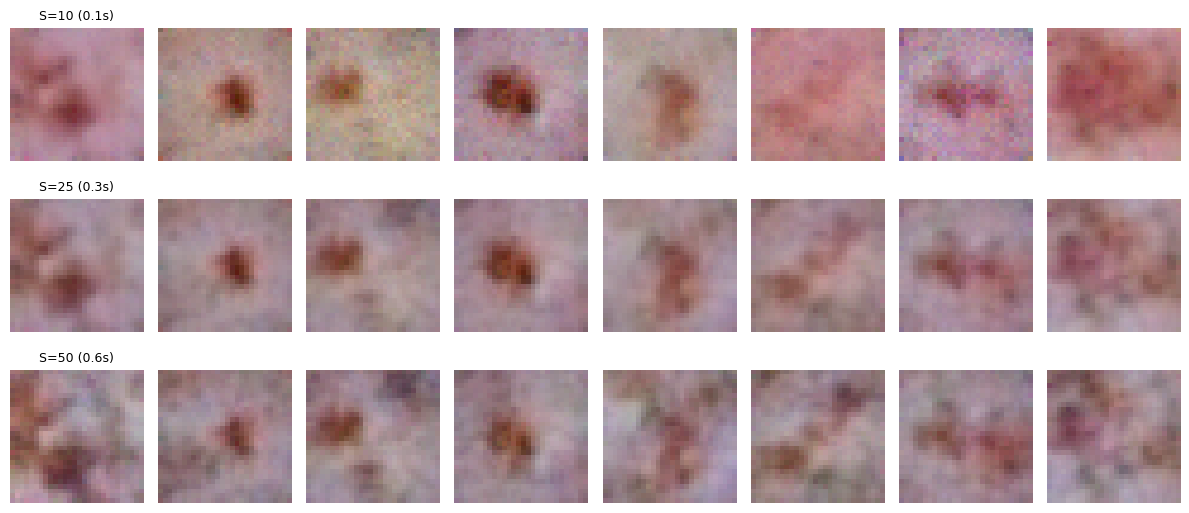

Même x_T -> même 'identité' d'image à tous les S (ODE) ; S=10 reste lisible, S=50 affine les détails.


In [12]:
# --- 3) Effet du nombre de pas S (même x_T pour toutes les lignes) ---
rows, titles = [], []
for S in (10, 25, 50):
    t0 = time.time()
    g = ddim_sample(unet, 8, steps=S, x_T=x_T)
    dt = time.time() - t0
    rows.append(g)
    titles += [f"S={S} ({dt:.1f}s)"] + [""] * 7
imgs = [to01(img) for g in rows for img in g]
show_grid(imgs, nrow=8, titles=titles, figsize=(12, 5.4))
print("Même x_T -> même 'identité' d'image à tous les S (ODE) ; S=10 reste lisible, S=50 affine les détails.")

**Interprétation — DDIM : ×38 plus rapide, déterministe, même réseau.** DDIM **réutilise le réseau déjà entraîné** (zéro réentraînement) mais échantillonne sur une **sous-suite** de pas. Trois faits mesurés : (1) **accélération ≈ ×38** par image (S=50 en 0,6 s contre 1000 pas DDPM) ; (2) avec $\eta=0$ (sigma nul), deux appels au **même $x_T$** donnent un **écart maximal de 0** : la trajectoire est une **ODE déterministe** ⇒ $x_T$ est un *latent reproductible* (interpolation possible) ; (3) en faisant varier $S$, le **même $x_T$ produit la même « identité » d'image** — `S=10` reste lisible, `S=50` affine les détails. C'est exactement le compromis du deck : **entraîner en DDPM** ($T=1000$), **échantillonner en DDIM** ($S\ll T$).

## Partie VIII — Situer la diffusion : AE → VAE → DDPM (→ GAN)

Bilan des trois TP du Module 3, complété par le GAN (Module 4) :

| Critère | AE (TP 07) | VAE (TP 08) | GAN (M4) | Diffusion (TP 09) |
|---------|-----------|-------------|----------|--------------------|
| Génère ? | ✗ (pas de prior) | ✓ | ✓ | ✓ |
| Qualité | — | moyenne (flou) | élevée | **très élevée** |
| Diversité | — | bonne | faible (*mode collapse*) | **excellente** |
| Stabilité d'entraînement | stable | **stable** | instable | **stable** (simple MSE) |
| Vitesse d'échantillonnage | 1 passe | **1 passe** | **1 passe** | lente ($S$ pas) |
| Latent | explicite | explicite | implicite | implicite |

Liens entre les trois TP : le **U-Net débruiteur** vient du TP 07 ; la **borne variationnelle** et la reparamétrisation viennent du TP 08 — la diffusion est un *VAE hiérarchique à $T$ niveaux* dont l'encodeur est fixé (le bruitage). Et le flou du VAE disparaît : le débruitage itératif reconstruit les hautes fréquences pas à pas.

**Cas d'usage** (cf. déck) : texte→image (*Latent Diffusion* : diffusion dans le latent d'un VAE !), inpainting, super-résolution, **augmentation de données médicales** (synthèse IRM/CT pour classes rares), génération/imputation de signaux capteurs.

## Partie IX — Prototypage avec `diffusers` (Hugging Face)

En production, on ne recode pas le scheduler : la bibliothèque `diffusers` fournit `UNet2DModel` (U-Net conditionné par le timestep prêt à l'emploi), `DDPMScheduler` / `DDIMScheduler` (gèrent $\beta_t, \alpha_t, \bar\alpha_t$ et les pas inverses) et `DDPMPipeline`. Bonne pratique : **entraîner** avec `DDPMScheduler` ($T=1000$) puis **échantillonner** avec `DDIMScheduler` ($S=50$).

Le code ci-dessous vérifie que `DDPMScheduler.add_noise` coïncide avec notre `q_sample` *from scratch* — il est gardé par un flag pour rester exécutable sans la bibliothèque.

In [13]:
try:
    from diffusers import UNet2DModel, DDPMScheduler
    HAS_DIFFUSERS = True
except ImportError:
    HAS_DIFFUSERS = False
    print("diffusers non installé — section de prototypage sautée (pip install diffusers).")

if HAS_DIFFUSERS:
    sched = DDPMScheduler(num_train_timesteps=T, beta_start=1e-4, beta_end=0.02,
                          beta_schedule="linear")
    x0 = x_batch[:4].to(device)
    torch.manual_seed(SEED)
    noise = torch.randn_like(x0)
    t_chk = torch.tensor([10, 250, 500, 900], device=device)
    x_t_lib  = sched.add_noise(x0, noise, t_chk)
    x_t_ours = q_sample(x0, t_chk, noise)
    print(f"add_noise (diffusers) vs q_sample (from scratch) : écart max = "
          f"{(x_t_lib - x_t_ours).abs().max():.2e}")
    model_hf = UNet2DModel(
        sample_size=IMG_SIZE, in_channels=3, out_channels=3,
        block_out_channels=(32, 64, 128),
        down_block_types=("DownBlock2D", "AttnDownBlock2D", "DownBlock2D"),
        up_block_types=("UpBlock2D", "AttnUpBlock2D", "UpBlock2D"))
    print(f"UNet2DModel — paramètres : {sum(p.numel() for p in model_hf.parameters()):,} "
          f"(vs notre TinyUNet : {count_params(unet):,})")

diffusers non installé — section de prototypage sautée (pip install diffusers).


## Partie X — Sauvegarde du modèle

Convention du dépôt : `<arch>_<dataset>_best.pt`. On embarque le schedule ($T$, bornes de $\beta$) : **un checkpoint de diffusion est inutilisable sans son schedule**.

In [14]:
def save_ckpt(model, name, extra=None):
    path = CKPT_DIR / name
    payload = {"state_dict": model.state_dict(), "img_size": IMG_SIZE, "arch": type(model).__name__}
    if extra:
        payload.update(extra)
    torch.save(payload, path)
    print(f"✓ {path}  ({path.stat().st_size/1e6:.1f} Mo)")

save_ckpt(unet, "ddpm_unet_dermamnist_best.pt",
          extra={"T": T, "beta_start": 1e-4, "beta_end": 0.02,
                 "schedule": "linear", "final_loss": hist[-1]})

✓ checkpoints/ddpm_unet_dermamnist_best.pt  (4.5 Mo)


## Partie XI — Exercices d'application

### Exercice 1 — Schedule cosinus
Remplacez le schedule linéaire par le cosinus de la Partie III (récupérez $\beta_t = 1 - \bar\alpha_t/\bar\alpha_{t-1}$, clippé à $0.999$) et réentraînez. Comparez les échantillons à budget d'epochs égal : le gain est-il visible à 28×28 ? Reliez aux courbes de SNR.

### Exercice 2 — Réduire $T$
Réentraînez avec $T=200$ en **remettant $\beta_t$ à l'échelle** pour conserver $\bar\alpha_T \approx 0$ (vérifiez-le numériquement comme en Partie III !). Comparez qualité et temps de sampling DDPM. Que se passe-t-il si l'on réduit $T$ sans toucher aux $\beta_t$ ?

### Exercice 3 — La famille $\eta$ de DDIM
Le paramètre `eta` de `ddim_sample` interpole entre DDIM ($\eta=0$) et DDPM ($\eta=1$, $\sigma_t = \sqrt{\tilde\beta_t}$). Avec le même $\mathbf{x}_T$ et $S=50$, comparez $\eta \in \{0, 0.5, 1\}$ : que devient le déterminisme ? La diversité ?

### Exercice 4 — Coude qualité / nombre de pas
Balayez $S \in \{5, 10, 20, 50, 100, 250\}$ (même $\mathbf{x}_T$) en mesurant le temps. Tracez temps vs $S$ et inspectez les grilles : où se situe le **coude** au-delà duquel les pas supplémentaires n'apportent plus rien ?

### Exercice 5 — Paramétrisation $\hat{\mathbf{x}}_0$
Modifiez l'entraînement pour prédire **l'image** $\mathbf{x}_0$ au lieu du bruit (`loss = MSE(model(x_t, t), x0)`), et adaptez le pas inverse (la relation $\hat{\boldsymbol{\epsilon}} = (\mathbf{x}_t - \sqrt{\bar\alpha_t}\,\hat{\mathbf{x}}_0)/\sqrt{1-\bar\alpha_t}$ permet de réutiliser les boucles existantes). Comparez la stabilité aux **grands** $t$ (où $\mathbf{x}_t$ ne contient presque plus de signal).

### Exercice 6 — Diffusion conditionnelle & Classifier-Free Guidance
Ajoutez un `nn.Embedding(7, t_dim)` de la classe, **additionné au time embedding**, et entraînez en remplaçant aléatoirement le label par un token « nul » (10 % du temps). À l'échantillonnage, appliquez le guidage $\tilde{\boldsymbol{\epsilon}} = \boldsymbol{\epsilon}_\theta(\varnothing) + w\,(\boldsymbol{\epsilon}_\theta(\mathbf{c}) - \boldsymbol{\epsilon}_\theta(\varnothing))$ avec $w \in \{0, 1, 3\}$. Générez chaque classe : que fait $w$ sur la fidélité à la classe et la diversité ?

### Exercice 7 — Débruitage & inpainting d'images réelles
(a) Bruitez une image de test au pas $t=300$ par saut direct, puis appliquez la boucle inverse **depuis $t=300$ seulement** : comparez ce « débruiteur génératif » au DAE du TP 07. (b) Variante *inpainting* (RePaint simplifié) : masquez un quadrant, et à chaque pas de la boucle inverse, **réimposez** les pixels connus par $\mathbf{x}_t^{\text{connu}} = $ saut direct de l'original — seul le quadrant masqué est généré.

---

## Synthèse — API PyTorch des modèles de diffusion

| Concept | API PyTorch |
|---------|-------------|
| Schedule linéaire | `betas = torch.linspace(1e-4, 0.02, T)` |
| $\alpha_t$, $\bar\alpha_t$ | `alphas = 1 - betas` ; `abar = torch.cumprod(alphas, dim=0)` |
| Saut direct $q(\mathbf{x}_t\vert\mathbf{x}_0)$ | `abar[t].sqrt()*x0 + (1-abar[t]).sqrt()*eps` |
| Loss DDPM ($L_{\text{simple}}$) | `F.mse_loss(model(x_t, t), eps)` |
| Time embedding | sinusoïdal → `nn.Linear`+`nn.SiLU`, **additionné** dans chaque ResBlock |
| Normalisation / activation | `nn.GroupNorm` + `F.silu` (pas de BatchNorm) |
| Self-attention spatiale | `nn.MultiheadAttention(C, heads, batch_first=True)` sur `(N, H·W, C)` |
| Pas inverse DDPM | `(x - betas[t]/(1-abar[t]).sqrt()*eps)/alphas[t].sqrt() + betas[t].sqrt()*z` |
| Pas DDIM ($\sigma=0$) | `ab_prev.sqrt()*x0_hat + (1-ab_prev).sqrt()*eps` |
| Sous-suite de pas | `torch.linspace(0, T-1, S).long()` |
| Score équivalent | `s = -eps_theta / (1 - abar[t]).sqrt()` |
| Prototypage | `diffusers` : `UNet2DModel`, `DDPMScheduler` / `DDIMScheduler` |

---

*Fin du TP 09 — et du **Module 3** (Autoencoders → VAE → Diffusion).* **Module 4** : *GAN (DCGAN, cGAN, Pix2Pix, SRGAN), Vision Transformers (ViT, Swin, SegFormer) et déploiement (TorchScript, ONNX)*.